# Project: Teaching an LLM to Reason

In this project, you will teach an LLM to use step-by-step reasoning to answer the question: "How many X's are there in the word Y?"

Counting letters in a word is a surprisingly complex task for an LLM. Just as human beings would not be able to answer such a question for longer words without breaking down the word into its individual letters and then counting them, LLMs cannot be similarly expected to be able to respond without using smaller reasoning steps.

For example, to count the number of o's in the word room, one could use the following reasoning:

```
Question: How many of the letter "o" are there in the word "room"
Answer: 2
Response:

<reasoning>
Letter-by-letter spelling:
1. r - 0 o's so far
2. o - 1 o's so far
3. o - 2 o's so far
4. m - 2 o's so far

The letter "o" appears 2 times in the word "room".
</reasoning>
<answer>
2
</answer>
```

In this project I will use the reinforcement learning method GRPO (Group Relative Policy Optimization, of DeepSeek fame) to take a large language model that has been fine-tuned for following instructions and teach it how to break a word down into its letters and then count the requested letter.

The following steps included in this Notebook:

* Create a letter-counting dataset
* Create the reward functions
* Train the model
* View the results compared to the original LLM model

NOTE: This notebook will have you focus on several important aspects of training a GPRO model using LoRA:

1. Configuring LoRA adapters for parameter-efficient fine tuning
2. Selecting reward functions that help the model efficiently find its way to the correct answer (also called reward shaping)
3. Finding hyperparameters that help the model increase the rewards earned more quickly and reliably
4. Learning how to start with smaller experiments and to work your way up to longer experiments.

## Set up the notebook

 Install dependencies needed for the project, namely `unsloth` and `vllm`, which are useful for fine-tuning LLMs with even just minimal VRAM.

In [1]:
# Load ipython-autotime to see how long each cell take to run
# No changes needed in this cell

!pip install -q ipython-autotime
%load_ext autotime

time: 218 μs (started: 2026-05-12 15:07:08 +00:00)


In [ ]:
# Verify there is enough GPU memory 

!nvidia-smi

Tue May 12 15:07:32 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 575.57.08              Driver Version: 575.57.08      CUDA Version: 12.9     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       On  |   00000000:00:1E.0 Off |                    0 |
| N/A   49C    P0             66W /   70W |    8579MiB /  15360MiB |     95%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
# Load the `Qwen 2.5 3B Instruct`, and set parameters for the project
# The first time unsloth is imported, it will do patch the modules

import unsloth

from unsloth import FastLanguageModel
import torch

max_seq_length = 384  


lora_rank = 8  # The lora_rank specifies the number of trainable parameters in the metrices
               # i chose 8 for the task as the complexity of the task is low, the model needs behavioral correction only.

# Load the Instruct model in 4-bit mode
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name="Qwen/Qwen2.5-3B-Instruct",
    max_seq_length=max_seq_length,
    load_in_4bit=True,  # We'll use quantization!
    fast_inference=True,  # This uses vllm for faster inference
    max_lora_rank=lora_rank,
    gpu_memory_utilization=0.5,  
)

model = FastLanguageModel.get_peft_model(
    model,
    r=lora_rank,
    target_modules=[
    
        # The key layers are included 
        # Attention modules (q, k, v, o) are most critical for this task as the model is required to match a specific letter 
        # the MLP modules are included for fine-tuning coverage 
        "q_proj", # Explain your choice
        "k_proj",
        "v_proj",
        "o_proj",
        "up_proj",
        "gate_proj",
        "down_proj"
    ],
    lora_alpha=lora_rank,
    use_gradient_checkpointing="unsloth",  # Unsloth enables longer contexts
    # See: https://github.com/unslothai/unsloth
)

/voc/data/venv2/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
INFO 05-12 15:11:04 [__init__.py:241] Automatically detected platform cuda.
ERROR 05-12 15:11:07 [fa_utils.py:57] Cannot use FA version 2 is not supported due to FA2 is only supported on devices with compute capability >= 8
🦥 Unsloth Zoo will now patch everything to make training faster!
INFO 05-12 15:11:29 [vllm_utils.py:688] Unsloth: Patching vLLM v1 graph capture
INFO 05-12 15:11:29 [vllm_utils.py:716] Unsloth: Patching vLLM v0 graph capture
==((====))==  Unsloth 2025.9.7: Fast Qwen2 patching. Transformers: 4.55.4. vLLM: 0.10.1.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.7.1+cu126. CUDA: 7.5. CUDA Toolkit: 12.6. Triton: 3.2.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.31. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
Unsloth: vLLM 

2026-05-12 15:11:57,690	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


INFO 05-12 15:11:58 [scheduler.py:222] Chunked prefill is enabled with max_num_batched_tokens=2048.
Unsloth: vLLM Bitsandbytes config using kwargs = {'load_in_8bit': False, 'load_in_4bit': True, 'bnb_4bit_compute_dtype': 'float16', 'bnb_4bit_quant_storage': 'uint8', 'bnb_4bit_quant_type': 'nf4', 'bnb_4bit_use_double_quant': True, 'llm_int8_enable_fp32_cpu_offload': False, 'llm_int8_has_fp16_weight': False, 'llm_int8_skip_modules': ['lm_head', 'multi_modal_projector', 'merger', 'modality_projection', 'model.layers.2.mlp', 'model.layers.3.mlp', 'model.layers.30.mlp'], 'llm_int8_threshold': 6.0}
INFO 05-12 15:11:58 [llm_engine.py:222] Initializing a V0 LLM engine (v0.10.1) with config: model='unsloth/qwen2.5-3b-instruct-unsloth-bnb-4bit', speculative_config=None, tokenizer='unsloth/qwen2.5-3b-instruct-unsloth-bnb-4bit', skip_tokenizer_init=False, tokenizer_mode=auto, revision=None, override_neuron_config={}, tokenizer_revision=None, trust_remote_code=False, dtype=torch.float16, max_seq_le

Loading safetensors checkpoint shards:   0% Completed | 0/1 [00:00<?, ?it/s]
Loading safetensors checkpoint shards: 100% Completed | 1/1 [00:01<00:00,  1.87s/it]
Loading safetensors checkpoint shards: 100% Completed | 1/1 [00:01<00:00,  1.87s/it]

Loading safetensors checkpoint shards:   0% Completed | 0/1 [00:00<?, ?it/s]
Loading safetensors checkpoint shards: 100% Completed | 1/1 [00:19<00:00, 19.04s/it]
Loading safetensors checkpoint shards: 100% Completed | 1/1 [00:19<00:00, 19.04s/it]


...

Capturing CUDA graph shapes: 100%|██████████| 19/19 [00:26<00:00,  1.38s/it]

INFO 05-12 15:13:35 [model_runner.py:1535] Graph capturing finished in 26 secs, took 0.42 GiB
INFO 05-12 15:13:35 [vllm_utils.py:728] Unsloth: Patched vLLM v0 graph capture finished in 26 secs.


INFO 05-12 15:13:36 [llm_engine.py:417] init engine (profile, create kv cache, warmup model) took 41.01 seconds
INFO 05-12 15:13:36 [llm.py:298] Supported_tasks: ['generate']
Unsloth: Just some info: will skip parsing ['layer_norm1', 'q_norm', 'input_layernorm', 'pre_feedforward_layernorm', 'norm2', 'post_layernorm', 'norm1', 'k_norm', 'post_attention_layernorm', 'layer_norm2', 'post_feedforward_layernorm']
Unsloth: Just some info: will skip parsing ['layer_norm1', 'q_norm', 'input_layernorm', 'pre_feedforward_layernorm', 'cross_attn_input_layernorm', 'norm2', 'cross_attn_post_attention_layernorm', 'post_layernorm', 'norm1', 'k_norm', 'post_attention_layernorm', 'layer_norm2', 'post_feedforward_layernorm']


Unsloth 2025.9.7 patched 36 layers with 36 QKV layers, 36 O layers and 36 MLP layers.


time: 3min 22s (started: 2026-05-12 15:10:26 +00:00)


## Try Prompt Engineering to Count Letters

Let's work on the system prompt a little to see if we can get the model to count the number of the letter `g` in `engage`.



In this step I will insure Writing clear instructions, breaking the problem down into steps (Chain-of-Thought prompting)
and Providing at least one example for the model to follow (Few-shot prompting)

In [ ]:
# First, will test with blank system prompt
SYSTEM_PROMPT = """"""
USER_PROMPT = 'How many of the letter "g" are there in the word "engage"'

# Convert the chat messages to a single string so the model can complete it
text_for_completion = tokenizer.apply_chat_template(
    conversation=[
        {"role": "system", "content": SYSTEM_PROMPT},
        {
            "role": "user",
            "content": USER_PROMPT,
        },
    ],
    tokenize=False,
    add_generation_prompt=True,
)

from vllm import SamplingParams

# Set the LLM sampling parameters
sampling_params = SamplingParams(
    temperature=0.8,
    top_p=0.95,
    max_tokens=2048,
)

# Generate the text completion
output = (
    model.fast_generate(
        [text_for_completion],
        sampling_params=sampling_params,
        lora_request=None,
    )[0]
    .outputs[0]
    .text
)

# Print the text input for the model and the model's output
print("=== TEXT FOR COMPLETION ===")
print(text_for_completion)
print("=== GENERATED OUTPUT ===")
print(output)

Processed prompts: 100%|██████████| 1/1 [00:06<00:00,  6.47s/it, est. speed input: 4.49 toks/s, output: 2.32 toks/s]

=== TEXT FOR COMPLETION ===
<|im_start|>system
<|im_end|>
<|im_start|>user
How many of the letter "g" are there in the word "engage"<|im_end|>
<|im_start|>assistant

=== GENERATED OUTPUT ===
In the word "engage", there is only one letter "g".
time: 6.48 s (started: 2026-05-12 15:14:45 +00:00)


Without any prompting the model will generate an output such as this:

```
=== GENERATED OUTPUT ===
There is one letter "g" in the word "engage".
```

Now let's work on the system prompt to help the model break this problem down into steps, which might help it get the right answer (2 `g`'s in `engage`)

In [ ]:
# Let's work on a new system prompt that will help the model break this problem
# TODO: Fill in the missing parts marked with **********


SYSTEM_PROMPT = """You are a professional conuter for the occurances of a specific letter in a given word.
Keep a counter when you are travesing through the word. 
Show the steps of spelling the letters of the word, counting the occurances
 and the status of the counter at each new letter. 
For example count the letter o in the word "Room"
R: 0 O's so far 
o: 1 O so far
0: 2 Os so far
m: 2 Os """


USER_PROMPT = 'How many of the letter "g" are there in the word "engage"'

# Convert the chat messages to a single string so the model can complete it
text_for_completion = tokenizer.apply_chat_template(
    conversation=[
        {"role": "system", "content": SYSTEM_PROMPT},
        {
            "role": "user",
            "content": USER_PROMPT,
        },
    ],
    tokenize=False,
    add_generation_prompt=True,
)

from vllm import SamplingParams

# Set the LLM sampling parameters
sampling_params = SamplingParams(
    temperature=0.8,
    top_p=0.95,
    max_tokens=2048,
)

# Generate the text completion
output = (
    model.fast_generate(
        [text_for_completion],
        sampling_params=sampling_params,
        lora_request=None,
    )[0]
    .outputs[0]
    .text
)

# Print the text input for the model and the model's output
print("=== TEXT FOR COMPLETION ===")
print(text_for_completion)
print("=== GENERATED OUTPUT ===")
print(output)

Processed prompts: 100%|██████████| 1/1 [00:13<00:00, 13.36s/it, est. speed input: 9.95 toks/s, output: 18.79 toks/s]

=== TEXT FOR COMPLETION ===
<|im_start|>system
You are a professional conuter for the occurances of a specific letter in a given word.
Keep a counter when you are travesing through the word. 
Show the steps of spelling the letters of the word, counting the occurances
 and the status of the counter at each new letter. 
For example count the letter o in the word "Room"
R: 0 O's so far 
o: 1 O so far
0: 2 Os so far
m: 2 Os <|im_end|>
<|im_start|>user
How many of the letter "g" are there in the word "engage"<|im_end|>
<|im_start|>assistant

=== GENERATED OUTPUT ===
Let's go through the word "engage" step by step, counting the occurrences of the letter "g":

1. **e:**
   - The first letter is "e". There are no "g"s so far.
   - **Status:** 0 g's so far.

2. **n:**
   - The second letter is "n". There are no "g"s so far.
   - **Status:** 0 g's so far.

3. **g:**
   - The third letter is "g". This is our first "g".
   - **Status:** 1 g so far.

4. **a:**
   - The fourth letter is "a". There a

Did your new prompt get the right answer? Did the model follow all of your instructions?

Maybe yes, maybe no. Either way, we'll want the model to reliably complete this challenge. So let's use GRPO to help it!

## Create a letter-counting dataset

To train a model, we'll first need to create a dataset. We'll use the HuggingFace `datasets` package.

In [ ]:
# Create a list of words of different lengths


ALL_WORDS = [
    "idea",
    "glow",
    "rust",
    "maze",
    "echo",
    "wisp",
    "veto",
    "lush",
    "gaze",
    "knit",
    "fume",
    "plow",
    "void",
    "oath",
    "grim",
    "crisp",
    "lunar",
    "fable",
    "quest",
    "verge",
    "brawn",
    "elude",
    "aisle",
    "ember",
    "crave",
    "ivory",
    "mirth",
    "knack",
    "wryly",
    "onset",
    "mosaic",
    "velvet",
    "sphinx",
    "radius",
    "summit",
    "banner",
    "cipher",
    "glisten",
    "mantle",
    "scarab",
    "expose",
    "fathom",
    "tavern",
    "fusion",
    "relish",
    "lantern",
    "enchant",
    "torrent",
    "capture",
    "orchard",
    "eclipse",
    "frescos",
    "triumph",
    "absolve",
    "gossipy",
    "prelude",
    "whistle",
    "resolve",
    "zealous",
    "mirage",
    "aperture",
    "sapphire",
]

print(len(ALL_WORDS))

ALL_WORDS[:10]

62


['idea',
 'glow',
 'rust',
 'maze',
 'echo',
 'wisp',
 'veto',
 'lush',
 'gaze',
 'knit']

time: 6.11 ms (started: 2026-05-12 15:16:28 +00:00)


In [ ]:


from datasets import Dataset
import random


# Go through the letters from the words (as well as letters not in the words),
# and create a labelled dataset with all the different combinations.
# For example for the word gaze:
# 1. How many i's are in idea? <-- count should be 1
# 2. How many d's are in idea? <-- count should be 1
# 3. How many e's are in idea? <-- count should be 1
# 4. How many a's are in idea? <-- count should be 1
# 5. How many b's are in idea? <-- a letter not in word (count should be zero)
def generate_records():
    for word in ALL_WORDS:
        for letter in sorted(set(word)):
            yield {"words": word, "letters": letter, "counts": word.count(letter)}

        # pick random letters not in the word
        num_letters_not_in_word_left = int(len(word) // 7 + 1)

        random.seed(hash(word))

        all_letters = list("abcdefghijklmnopqrstuvwxyz")

        random.shuffle(all_letters)
        for letter in all_letters:
            if letter not in word:
                yield {"words": word, "letters": letter, "counts": 0}
                num_letters_not_in_word_left -= 1
            if num_letters_not_in_word_left == 0:
                break


ds = Dataset.from_generator(generate_records)

# Show the first item
ds[0]

Generating train split: 401 examples [00:00, 3924.68 examples/s]


{'words': 'idea', 'letters': 'a', 'counts': 1}

time: 497 ms (started: 2026-05-12 15:16:34 +00:00)


In [ ]:
# Add the entire prompt (system + user) and the answer to the dataset
# We'll use a prompt that spells out the word letter-by-letter

import re
from datasets import load_dataset, Dataset

# Simple CoT prompt (zero-shot)
SYSTEM_PROMPT = """
Respond in the following format:
<reasoning>
Counting the number of [letter_to_count]'s in the word [word]
1. [first letter] - [count of requested letter so far] so far
2. [second letter] - [count of requested letter so far] so far
...
</reasoning>
<answer>
[number]
</answer>
"""

ds = ds.map(
    lambda x: {  # type: ignore
        "prompt": [
            {"role": "system", "content": SYSTEM_PROMPT},
            {
                "role": "user",
                "content": 'How many of the letter "{}" are there in the word "{}"'.format(
                    x["letters"], x["words"]
                ),
            },
        ],
    }
)

ds[0]

Map: 100%|██████████| 401/401 [00:00<00:00, 4278.51 examples/s]


{'words': 'idea',
 'letters': 'a',
 'counts': 1,
 'prompt': [{'content': "\nRespond in the following format:\n<reasoning>\nCounting the number of [letter_to_count]'s in the word [word]\n1. [first letter] - [count of requested letter so far] so far\n2. [second letter] - [count of requested letter so far] so far\n...\n</reasoning>\n<answer>\n[number]\n</answer>\n",
   'role': 'system'},
  {'content': 'How many of the letter "a" are there in the word "idea"',
   'role': 'user'}]}

time: 106 ms (started: 2026-05-12 15:16:45 +00:00)


In [ ]:
# Test how well the model runs out-of-the-box


text = tokenizer.apply_chat_template(
    ds[0]["prompt"], tokenize=False, add_generation_prompt=True
)

from vllm import SamplingParams

sampling_params = SamplingParams(
    temperature=0.8,
    top_p=0.95,
    max_tokens=1024,
)
output = (
    model.fast_generate(
        [text],
        sampling_params=sampling_params,
        lora_request=None,
    )[0]
    .outputs[0]
    .text
)

print(output)

Processed prompts: 100%|██████████| 1/1 [00:01<00:00,  1.73s/it, est. speed input: 60.65 toks/s, output: 37.55 toks/s]

<reasoning>
Counting the number of a's in the word idea
1. i - 0 so far
2. d - 1 so far
3. e - 2 so far
4. a - 3 so far
</reasoning>
<answer>
3
</answer>
time: 1.74 s (started: 2026-05-12 15:16:55 +00:00)


## Create Reward Functions

One goal of creating reward functions is to guide the model toward behaviors that help it reach its goal (counting the occurrences of a letter within a word) more easily. Since there is more than one way to carry out any step-by-step task (e.g. whether or not you use bullet points to separate your steps), there's a bit of judgement involved in choosing what behaviors to reward, i.e. how do we provide partial credit or "shape" our rewards?

In this case we will encourage the model to (whether or not this structure is best):
* use numbers for bullet points when spelling out the word
* to spell the word correctly
* to count the requested letter correctly
* to use the requested reasoning format
* to get the final answer correct.


### Numbering reward function

In [ ]:
# Let's work on a function that the numbering in the bullet points is correct
# When using GRPO, we lean on reward functions that are relatively easy to
# compute, thus removing the need to have a second large model just for
# evaluation.
# In this case, we'll use regular expressions.

def extract_letter_numbering(response):
    """Extract the numbers at the beginning of the line

    Example:
    1. g - 1 so far
    2. o - 1 so far
    3. a - 2 so far
    4. a - 2 so far
    5. l - 2 so far
    returns [1, 2, 3, 4, 5]
    """
    import re

    # We use a regular expression to find lines of the form:
    # '\n[number]. [letter]'
    pattern = r"\n(\d+). [a-z]"

    # Use `re` to find all matches of the pattern in the response
    matches = re.findall(pattern, response)
    if matches:
        return [int(m) for m in matches]
    return []


assert extract_letter_numbering(
    """
1. g - 1 so far
2. o - 1 so far
3. a - 2 so far
4. a - 2 so far
5. l - 2 so far
"""
) == [1, 2, 3, 4, 5]


def numbering_reward_func(completions, words, **kwargs) -> list[float]:
    """Provides a reward for getting the numbering at the beginning of the line correct

    1. g - 1 so far <-- Good in-order numbering
    2. o - 1 so far <-- Good in-order numbering
    3. a - 2 so far <-- Good in-order numbering
    3. l - 2 so far <-- Bad numbering, out-of-order, 3 should be 4
    1. l - 2 so far <-- Bad numbering, extra letter and out-of-order
    1. l - 2 so far <-- Bad numbering, extra letter and out-of-order

    """
    responses = [completion[0]["content"] for completion in completions]

    res = []
    for response, word in zip(responses, words):
        reward = 0

        for ix, spell_number in enumerate(extract_letter_numbering(response)):
            line_number = ix + 1

            # Get points for in-order numbering
            if spell_number == line_number:
              
                reward += 0.5
            # Otherwise lose points
            else:
              
                reward -= 0.5

            # Lose extra points for continuing beyond the length of the word
            if line_number > len(word):  # We use the index of the line
                # (positive for good behavior, negative for bad)
                reward -= 1.0

        res.append(reward / len(word))
    return res


res = numbering_reward_func(
    completions=[
        [
            {  # Worse response
                "content": """<reasoning>
Here is a letter by letter spelling:
1. g - 1 so far <-- Good in-order numbering
2. o - 1 so far <-- Good in-order numbering
3. a - 2 so far <-- Good in-order numbering
3. l - 2 so far <-- Bad numbering, out-of-order, 3 should be 4
1. l - 2 so far <-- Bad numbering, extra letter and out-of-order
1. l - 2 so far <-- Bad numbering, extra letter and out-of-order
</reasoning>
<answer>2</answer>"""
            },
        ],
        [
            {  # Better response
                "content": """<reasoning>
Here is a letter by letter spelling:
1. g - 1 so far <-- Good in-order numbering
2. o - 1 so far <-- Good in-order numbering
3. a - 2 so far <-- Good in-order numbering
3. l - 2 so far <-- Bad numbering, out-of-order, 3 should be 4
</reasoning>
<answer>2</answer>"""
            },
        ],
    ],
    words=["goal", "goal"],
)
print(res)

assert res[1] > res[0], "The better response should have a higher reward"

[-0.5, 0.25]
time: 3.42 ms (started: 2026-05-12 15:18:51 +00:00)


### Spelling reward function

In [ ]:
# Reward correct spelling of the word


def extract_spelling(response):
    """Extract the spelling from the response

    Example:
    1. g - 1 so far
    2. o - 1 so far
    3. a - 2 so far
    3. l - 2 so far
    5. l - 2 so far
    Returns "goall"
    """
    import re

    pattern = r"\n\d+. ([a-z])"
    matches = re.findall(pattern, response, flags=re.IGNORECASE)
    if matches:
        return "".join([m for m in matches])
    return ""


extract_spelling(
    """Here is a letter by letter spelling:

1. g - 1 so far
2. o - 1 so far
3. a - 2 so far
3. l - 2 so far
5. l - 2 so far
"""
) == "goall"


def spelling_reward_func(completions, words, **kwargs) -> list[float]:
    """A spelling reward function."""
    from collections import Counter

    responses = [completion[0]["content"] for completion in completions]

    res = []

    for word, response in zip(words, responses):
        reward = 0.0

        extracted = extract_spelling(response)

        # Provide a reward for exactly correct spelling
        if extracted == word:
            reward += 2.0

        # Provide a reward for each letter of difference in length
        reward -= abs(len(extracted) - len(word)) # each difference in letters length adds a penality 

        # Provide a reward for each letter that is not in the target word
        extra = Counter(extracted) - Counter(word)
        reward -= sum(extra.values())

        # Provide a reward for each letter that is in the target word but not in the response
        missing = Counter(word) - Counter(extracted)
        reward -= sum(missing.values())

        res.append(reward)
    return res


res = spelling_reward_func(
    completions=[
        [  # Worse response
            {
                "content": """<reasoning>
Here is a letter by letter spelling:
1. g - 1 so far
2. o - 1 so far
3. a - 2 so far
4. l - 2 so far
5. l - 2 so far
</reasoning>
<answer>2</answer>"""
            }
        ],
        [  # Better Response
            {
                "content": """<reasoning>
Here is a letter by letter spelling:
1. g - 1 so far
2. o - 1 so far
3. a - 2 so far
4. l - 2 so far
</reasoning>
<answer>2</answer>"""
            }
        ],
    ],
    words=["goal", "goal"],
)

print(res)

assert res[1] > res[0], "The better response should have a higher reward"

[-2.0, 2.0]
time: 2.66 ms (started: 2026-05-12 15:21:57 +00:00)


### Counting reward function

In [ ]:
# Reward the model for properly counting the occurrences of a letter in a word


def get_resp_letters_and_counts(response):
    """Extract the letters and counts from the response

    Example:
    1. g - 1 so far
    2. o - 1 so far
    3. a - 2 so far
    4. a - 2 so far
    5. l - 2 so far
    returns [('g', 1), ('o', 1), ('a', 2), ('a', 2), ('l', 2)]
    """
    import re

    pattern = r"\n(\d+)\. ([a-z])\D*(\d+)"

    # Find strings matching e.g. "2. a - 2 so far"
    matches = re.findall(pattern, response, flags=re.IGNORECASE)

    if not matches:
        return []

    return [
        (matched_letter, matched_count_so_far)
        for _, matched_letter, matched_count_so_far in matches
    ]


assert get_resp_letters_and_counts(
    """
1. g - 1 so far
2. o - 1 so far
3. a - 2 so far
4. a - 2 so far
5. l - 2 so far
"""
) == [("g", "1"), ("o", "1"), ("a", "2"), ("a", "2"), ("l", "2")]


def counting_reward_func(completions, letters, **kwargs) -> list[float]:
    responses = [completion[0]["content"] for completion in completions]

    res = []

    # Iterate over each of the letter-response pairs
    for letter, response in zip(letters, responses):
        reward = 0

        letters_and_counts = get_resp_letters_and_counts(response)

        # If there are no matches, provide a negative reward
        if not letters_and_counts:
            res.append(-1)
            continue

        # Start counting the matching letters
        actual_count = 0
        for resp_letter, resp_count in letters_and_counts:
            # If there's a match, count the letter
            if letter == resp_letter:
                actual_count += 1

            # If the count is accurate, add a reward, else subtract a reward
            if int(resp_count) == actual_count:
                reward += 1.0
            else:
                reward -= 1.0

        # Return the reward normalized by the length of the matches
        res.append(reward / len(letters_and_counts))
    return res


res = counting_reward_func(
    completions=[
        [  # Worse response
            {
                "content": """<reasoning>\nHere is a letter by letter spelling:

1. g - 0 so far
2. o - 0 so far
3. a - 1 so far
4. a - 2 so far
5. l - 0 so far

\n</reasoning>\n<answer>\nThis is my answer.\n</answer>"""
            }
        ],
        [  # Better response
            {
                "content": """<reasoning>\nHere is a letter by letter spelling:

1. g - 1 so far
2. o - 1 so far
3. a - 1 so far
4. a - 1 so far
5. l - 1 so far

\n</reasoning>\n<answer>\nThis is my answer.\n</answer>"""
            }
        ],
    ],
    letters=["g", "g"],
)

print(res)

assert res[1] > res[0], "The better response should have a higher reward"


[-0.6, 1.0]
time: 3.24 ms (started: 2026-05-12 15:23:46 +00:00)


### Formatting reward functions



In [ ]:
# Reward the model for providing the response in a specific format


def extract_xml_answer(text: str) -> str:
    """Extracts the string between <answer> and </answer> tags."""
    import re

    pattern = r"<answer>(.*?)</answer>"
    match = re.search(pattern, text, re.DOTALL)
    if match:
        return match.group(1).strip()
    return ""


assert (
    extract_xml_answer("""
<reasoning>
This is my reasoning.
</reasoning>
<answer>SUPERCALIFRAGILISTICEXPIALIDOCIOUS</answer>
""")
    == "SUPERCALIFRAGILISTICEXPIALIDOCIOUS"
)


def format_reward_func(completions, **kwargs) -> list[float]:
    """Reward function that checks if the completion has a specific format."""
    pattern = r"\s*<reasoning>.*?</reasoning>\s*<answer>.*?</answer>"

    res = []

    for completion in completions:
        reward = 0.0

        # Extract the response content
        response = completion[0]["content"]

        # Check if the response matches the pattern
        match = re.match(pattern, response, flags=re.MULTILINE | re.DOTALL)

        # If it matches, return 0.5, otherwise return 0.0
        if match:
            reward +=0.5
        # Extract the answer from the response
        extracted_answer = extract_xml_answer(response)
        # If the answer is an integer, add 0.5 to the reward
        if extracted_answer.lstrip('-').isdigit():  # handling negative digits
            reward +=0.5

        res.append(reward)
    return res


res = format_reward_func(
    completions=[
        [{"content": "This is my answer"}],
        [
            {
                "content": "<reasoning>\nThis is my reasoning.\n</reasoning>\n<answer>\n3\n</answer>"
            }
        ],
    ]
)

print(res)

assert res[1] > res[0], "The better response should have a higher reward"

[0.0, 1.0]
time: 2.52 ms (started: 2026-05-12 15:25:52 +00:00)


### Task correctness reward function

In [ ]:
# Reward the model for providing the correct answer



def correct_answer_reward_func(prompts, completions, counts, **kwargs) -> list[float]:
    """Reward the final answer if it is correct."""
    responses = [completion[0]["content"] for completion in completions]

    extracted_responses = [extract_xml_answer(r) for r in responses]

    # Print a nice summary of the first prompt, answer, and response to see while training
    print(f"""
{"-" * 20}
Question: {prompts[0][-1]["content"]}
Answer: {counts[0]}
Response: {responses[0]}
Extracted: {extracted_responses[0]}
Correct: {str(extracted_responses[0]) == str(counts[0])}!
    """)

    res = [
        # Provide reward for exactly correct answer
        2.0 if str(r) == str(a) else -1.0
        for r, a in zip(extracted_responses, counts)
    ]
    return res


res = correct_answer_reward_func(
    prompts=[
        [{"content": """How many..."""}],
        [{"content": """How many..."""}],
    ],
    completions=[
        [{"content": """<reasoning>.../reasoning>\n<answer>\n3\n</answer>"""}],
        [{"content": """<reasoning>.../reasoning>\n<answer>\n3\n</answer>"""}],
    ],
    letters=["g", "g"],
    counts=[0, 3],
)

print(res)

assert res[1] > res[0], "The better response should have a higher reward"


--------------------
Question: How many...
Answer: 0
Response: <reasoning>.../reasoning>
<answer>
3
</answer>
Extracted: 3
Correct: False!
    
[-1.0, 2.0]
time: 2.42 ms (started: 2026-05-12 15:27:44 +00:00)


### List the reward functions

In [ ]:
# List out the reward functions we will use

REWARD_FUNCS = [
    numbering_reward_func,
    spelling_reward_func,
    counting_reward_func,
    format_reward_func,
    correct_answer_reward_func,
]

time: 438 μs (started: 2026-05-12 15:27:53 +00:00)


## Train the model

Now set up GRPO Trainer and configurations!

As you run the trainer, the goal is to see the various `reward` columns increase.

After 50 steps or more, you may notice some of the reward standard deviations begin to decrease, meaning that the different predictions are starting to converge on solutions that give similar rewards. If your model has learned the task, then you'll see the `correct_answer_reward_function` increase to its highest value (check the function to see what that is).

Here is an example, which successfully converged on a higher reward. Note, the values you see here will probably be different from yours, especially if your reward amounts are different.

| Step | Training Loss | reward   | reward_std | ... | kl      | rewards / correct_answer_reward_function / mean | rewards / correct_answer_reward_function / std |
|------|---------------|----------|------------|-----|---------|------------------------------------------|-----------------------------------------|
| 1    | 0.000000      | 7.961805 | 2.368493   | ... | 0.020369| 0.875000                                 | 1.024695                                |
| 2    | 0.000000      | 7.937500 | 1.352467   | ... | 0.016483| 0.875000                                 | 1.024695                                |
| 3    | 0.000000      | 1.894792 | 6.462189   | ... | 0.013677| 0.375000                                 | 0.806226                                |
| ...  | ...           | ...      | ...        | ... | ...     | ...                                      | ...                                     |
| 398  | 0.000100      | 13.000000| 0.000000   | ... | 0.088529| 2.000000                                 | 0.000000                                |
| 399  | 0.000100      | 13.000000| 0.000000   | ... | 0.088617| 2.000000                                 | 0.000000                                |
| 400  | 0.000100      | 13.000000| 0.000000   | ... | 0.096202| 2.000000                                 | 0.000000                                |


In [ ]:
# Set the GRPO Parameters 


COMMON_GRPO_TRAINING_PARAMS = dict(
    learning_rate=5e-6,  # based on docs this rate is perfered for GRPO
    beta= 0.04,
  
    per_device_train_batch_size=8,  # per_device_train_batch_size / num_generations determines the number of simultaneous prompts to consider.

    num_generations=4,  # Determines the number of completions/generations to compute for each single prompt
    gradient_accumulation_steps=4,  # This parameter allow us to consider multiple steps in a single optimization step
    adam_beta1=0.9,
    adam_beta2=0.99,
    weight_decay=0.1,
    warmup_ratio=0.1,
    lr_scheduler_type="cosine",
    optim="adamw_8bit",
    logging_steps=1,
    max_prompt_length=256,
    max_completion_length=200,
    num_train_epochs=1,  # Set to 1 for a full training run
    save_steps=250,
    max_grad_norm=0.1,
    report_to="none",  # Setting this value lets us use Weights and Biases
    output_dir="outputs",
    use_vllm=True,  # vll speeds up inference! 
)

time: 985 μs (started: 2026-05-12 15:29:16 +00:00)


### Quick train

Let's train the model for just 5 steps (`max_steps=5`). As it runs we can double check we've set up our prompts correctly before running for a longer amount of time.

In [ ]:
# Train for just a few steps for a few minutes
# This will allow us to observe the results and make any changes to our reward functions
# before starting a longer run. Not much change is expected.

from trl import GRPOConfig, GRPOTrainer

# Short train to check on reward functions
training_args = GRPOConfig(
    **COMMON_GRPO_TRAINING_PARAMS,
    # We'll just run for a modest 5 steps to make sure everything works and to
    # estimate the amount of time it will take to run the full training.
    max_steps=5,
)
trainer = GRPOTrainer(
    model=model,
    processing_class=tokenizer,
    reward_funcs=REWARD_FUNCS,
    args=training_args,
    train_dataset=ds,
)
trainer_res = trainer.train()

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 401 | Num Epochs = 1 | Total steps = 5
O^O/ \_/ \    Batch size per device = 8 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (8 x 4 x 1) = 32
 "-____-"     Trainable parameters = 14,966,784 of 3,100,905,472 (0.48% trained)


WARNING 05-12 15:29:38 [scheduler.py:1775] Sequence group 34 is preempted by PreemptionMode.RECOMPUTE mode because there is not enough KV cache space. This can affect the end-to-end performance. Increase gpu_memory_utilization or tensor_parallel_size to provide more KV cache memory. total_num_cumulative_preemption=1

--------------------
Question: How many of the letter "g" are there in the word "glisten"
Answer: 1
Response: <reasoning>
Counting the number of g's in the word glisten
1. g - 1 so far
2. l - 0 so far
3. i - 0 so far
4. s - 0 so far
5. t - 0 so far
6. e - 0 so far
7. n - 0 so far
</reasoning>
<answer>
1
</answer>
Extracted: 1
Correct: True!
    
Unsloth: Will smartly offload gradients to save VRAM!


Step,Training Loss,reward,reward_std,completions / mean_length,completions / min_length,completions / max_length,completions / clipped_ratio,completions / mean_terminated_length,completions / min_terminated_length,completions / max_terminated_length,kl,rewards / numbering_reward_func / mean,rewards / numbering_reward_func / std,rewards / spelling_reward_func / mean,rewards / spelling_reward_func / std,rewards / counting_reward_func / mean,rewards / counting_reward_func / std,rewards / format_reward_func / mean,rewards / format_reward_func / std,rewards / correct_answer_reward_func / mean,rewards / correct_answer_reward_func / std
1,-0.000000,0.865544,2.715819,79.343750,38.000000,112.000000,0.000000,79.343750,38.000000,112.000000,0.000000,0.396819,0.140777,-1.500000,3.482676,-0.000025,0.685618,1.000000,0.000000,0.968750,1.447676
2,-0.000000,0.082887,1.668280,81.593750,39.000000,135.000000,0.000000,81.593750,39.000000,135.000000,0.000010,0.444196,0.122135,-1.500000,3.835320,0.107440,0.758507,1.000000,0.000000,0.031250,1.447676
3,0.000000,1.497842,1.398141,79.500000,56.000000,102.000000,0.000000,79.500000,56.000000,102.000000,0.000005,0.426339,0.099529,-0.812500,2.146828,0.290253,0.699198,1.000000,0.000000,0.593750,1.521022
4,0.000000,-1.207912,2.116737,85.031250,44.000000,125.000000,0.000000,85.031250,44.000000,125.000000,0.000013,0.395461,0.068667,-2.937500,1.899703,0.115377,0.739954,1.000000,0.000000,0.218750,1.496973
5,0.000000,-0.506585,1.049729,77.656250,39.000000,102.000000,0.000000,77.656250,39.000000,102.000000,0.000007,0.382254,0.142254,-2.125000,3.799406,0.298661,0.588928,1.000000,0.000000,-0.062500,1.412787



--------------------
Question: How many of the letter "t" are there in the word "absolve"
Answer: 0
Response: <reasoning>
Counting the number of t's in the word absolve
1. a - 0 so far
2. b - 0 so far
3. s - 1 so far
4. a - 1 so far
5. b - 1 so far
6. o - 2 so far
7. v - 2 so far
8. e - 3 so far
</reasoning>
<answer>
3
</answer>
Extracted: 3
Correct: False!
    

--------------------
Question: How many of the letter "r" are there in the word "crave"
Answer: 1
Response: <reasoning>
Counting the number of r's in the word crave
1. c - 0 so far
2. r - 1 so far
3. a - 1 so far
4. v - 1 so far
5. e - 1 so far
</reasoning>
<answer>
1
</answer>
Extracted: 1
Correct: True!
    

--------------------
Question: How many of the letter "v" are there in the word "absolve"
Answer: 1
Response: <reasoning>
Counting the number of v's in the word "absolve"
1. a - 0 so far
2. b - 0 so far
3. s - 1 so far
4. v - 1 so far
</reasoning>
<answer>
2
</answer>
Extracted: 2
Correct: False!
    
WARNING 05-12 15:

available columns: dict_keys(['loss', 'grad_norm', 'learning_rate', 'num_tokens', 'completions/mean_length', 'completions/min_length', 'completions/max_length', 'completions/clipped_ratio', 'completions/mean_terminated_length', 'completions/min_terminated_length', 'completions/max_terminated_length', 'rewards/numbering_reward_func/mean', 'rewards/numbering_reward_func/std', 'rewards/spelling_reward_func/mean', 'rewards/spelling_reward_func/std', 'rewards/counting_reward_func/mean', 'rewards/counting_reward_func/std', 'rewards/format_reward_func/mean', 'rewards/format_reward_func/std', 'rewards/correct_answer_reward_func/mean', 'rewards/correct_answer_reward_func/std', 'reward', 'reward_std', 'frac_reward_zero_std', 'completion_length', 'kl', 'epoch', 'step'])


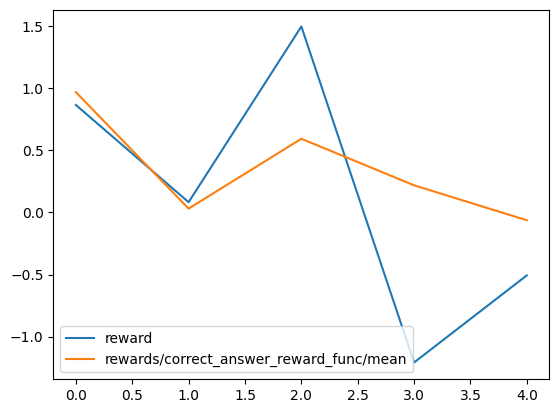

time: 3.51 s (started: 2026-05-12 15:33:30 +00:00)


In [ ]:
# Show the total (sum) of the rewards as well as the correct_answer_reward_func (means with in the batch)

import pandas as pd
import matplotlib.pyplot as plt

# If you want to graph other columns, check these out
print(f"available columns: {trainer.state.log_history[0].keys()}")

log_df = pd.DataFrame(trainer.state.log_history)
log_df["reward"].plot()
log_df["rewards/correct_answer_reward_func/mean"].plot()

# Show the legend
plt.legend(["reward", "rewards/correct_answer_reward_func/mean"])
plt.show()

### Slower train (1+ hour)



In [ ]:
# This is longer training that will take an hour or more


# Full training
training_args = GRPOConfig(
    **COMMON_GRPO_TRAINING_PARAMS,
   
    max_steps=90,  # ~60min 
)
trainer = GRPOTrainer(
    model=model,
    processing_class=tokenizer,
    reward_funcs=REWARD_FUNCS,
    args=training_args,
    train_dataset=ds,
)
trainer_res = trainer.train()

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 401 | Num Epochs = 2 | Total steps = 90
O^O/ \_/ \    Batch size per device = 8 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (8 x 4 x 1) = 32
 "-____-"     Trainable parameters = 14,966,784 of 3,100,905,472 (0.48% trained)



--------------------
Question: How many of the letter "g" are there in the word "glisten"
Answer: 1
Response: <reasoning>
Counting the number of g's in the word glisten
1. g - 1 so far
2. i - 1 so far
3. s - 1 so far
4. e - 1 so far
5. n - 1 so far
6. t - 1 so far
7. l - 1 so far
8. g - 2 so far
</reasoning>
<answer>
2
</answer>
Extracted: 2
Correct: False!
    


Step,Training Loss,reward,reward_std,completions / mean_length,completions / min_length,completions / max_length,completions / clipped_ratio,completions / mean_terminated_length,completions / min_terminated_length,completions / max_terminated_length,kl,rewards / numbering_reward_func / mean,rewards / numbering_reward_func / std,rewards / spelling_reward_func / mean,rewards / spelling_reward_func / std,rewards / counting_reward_func / mean,rewards / counting_reward_func / std,rewards / format_reward_func / mean,rewards / format_reward_func / std,rewards / correct_answer_reward_func / mean,rewards / correct_answer_reward_func / std
1,0.000000,-0.203919,2.617141,79.000000,38.000000,153.000000,0.000000,79.000000,38.000000,153.000000,0.000009,0.375893,0.146398,-2.187500,3.421351,0.013938,0.629698,1.000000,0.000000,0.593750,1.521022
2,-0.000000,0.082887,1.668280,81.593750,39.000000,135.000000,0.000000,81.593750,39.000000,135.000000,0.000010,0.444196,0.122135,-1.500000,3.835320,0.107440,0.758507,1.000000,0.000000,0.031250,1.447676
3,0.000000,1.290104,1.742053,80.000000,56.000000,121.000000,0.000000,80.000000,56.000000,121.000000,0.000003,0.417039,0.097207,-1.000000,2.214323,0.279316,0.685782,1.000000,0.000000,0.593750,1.521022
4,0.000000,-0.239162,2.949774,84.375000,66.000000,140.000000,0.000000,84.375000,66.000000,140.000000,0.000013,0.411384,0.088884,-2.187500,2.752565,0.224454,0.684462,1.000000,0.000000,0.312500,1.512048
5,0.000000,-0.052158,1.508606,80.812500,39.000000,112.000000,0.000000,80.812500,39.000000,112.000000,0.000010,0.389137,0.130110,-1.750000,3.583114,0.089955,0.667570,1.000000,0.000000,0.218750,1.496973
6,0.000000,-1.702319,2.361133,89.187500,47.000000,140.000000,0.000000,89.187500,47.000000,140.000000,0.000012,0.379129,0.093025,-3.687500,2.693331,0.293552,0.672174,1.000000,0.000000,0.312500,1.512048
7,0.000000,-0.200409,2.894725,80.218750,38.000000,150.000000,0.000000,80.218750,38.000000,150.000000,0.000020,0.413504,0.105149,-2.562500,2.395392,0.354836,0.736099,1.000000,0.000000,0.593750,1.521022
8,0.000000,0.496652,1.905357,76.093750,38.000000,144.000000,0.000000,76.093750,38.000000,144.000000,0.000017,0.386161,0.153916,-1.812500,3.604992,0.422991,0.635472,1.000000,0.000000,0.500000,1.524001
9,0.000000,-1.568421,2.219642,96.125000,75.000000,143.000000,0.000000,96.125000,75.000000,143.000000,0.000020,0.414211,0.090224,-2.750000,2.994619,-0.170132,0.666243,1.000000,0.000000,-0.062500,1.412787
10,0.000000,-0.887401,2.884630,88.968750,39.000000,200.000000,0.031250,85.387093,39.000000,124.000000,0.000024,0.374330,0.093534,-3.062500,2.381887,0.425769,0.600853,0.968750,0.176777,0.406250,1.521022



--------------------
Question: How many of the letter "t" are there in the word "absolve"
Answer: 0
Response: <reasoning>
Counting the number of t's in the word absolve
1. a - 0 so far
2. b - 0 so far
3. s - 1 so far
4. a - 1 so far
5. b - 1 so far
6. o - 2 so far
7. v - 2 so far
8. e - 3 so far
</reasoning>
<answer>
3
</answer>
Extracted: 3
Correct: False!
    

--------------------
Question: How many of the letter "r" are there in the word "crave"
Answer: 1
Response: <reasoning>
Counting the number of r's in the word crave
1. c - 0 so far
2. r - 1 so far
3. a - 1 so far
4. v - 1 so far
5. e - 1 so far
</reasoning>
<answer>
1
</answer>
Extracted: 1
Correct: True!
    

--------------------
Question: How many of the letter "v" are there in the word "absolve"
Answer: 1
Response: <reasoning>
Counting the number of v's in the word absolve
1. a - 0 so far
2. b - 0 so far
3. s - 0 so far
4. v - 1 so far
5. e - 1 so far
6. l - 1 so far
7. o - 1 so far
</reasoning>
<answer>
1
</answer>
Extra

available columns: dict_keys(['loss', 'grad_norm', 'learning_rate', 'num_tokens', 'completions/mean_length', 'completions/min_length', 'completions/max_length', 'completions/clipped_ratio', 'completions/mean_terminated_length', 'completions/min_terminated_length', 'completions/max_terminated_length', 'rewards/numbering_reward_func/mean', 'rewards/numbering_reward_func/std', 'rewards/spelling_reward_func/mean', 'rewards/spelling_reward_func/std', 'rewards/counting_reward_func/mean', 'rewards/counting_reward_func/std', 'rewards/format_reward_func/mean', 'rewards/format_reward_func/std', 'rewards/correct_answer_reward_func/mean', 'rewards/correct_answer_reward_func/std', 'reward', 'reward_std', 'frac_reward_zero_std', 'completion_length', 'kl', 'epoch', 'step'])


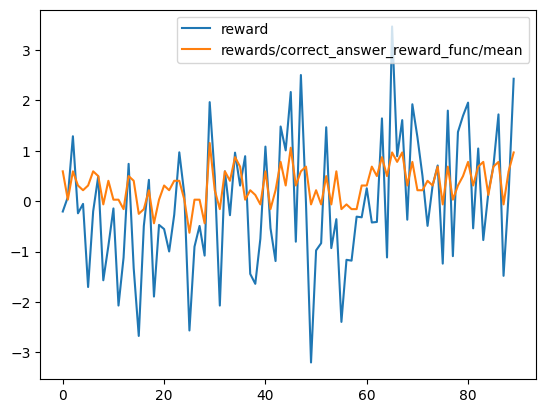

time: 244 ms (started: 2026-05-12 16:30:36 +00:00)


In [ ]:
# Show the total (sum) of the rewards as well as the correct_answer_reward_func (means with in the batch)


import pandas as pd
import matplotlib.pyplot as plt

# If you want to graph other columns, check these out
print(f"available columns: {trainer.state.log_history[0].keys()}")

log_df = pd.DataFrame(trainer.state.log_history)
log_df["reward"].plot()
log_df["rewards/correct_answer_reward_func/mean"].plot()

# Show the legend
plt.legend(["reward", "rewards/correct_answer_reward_func/mean"])
plt.show()

## View the results
Now let's try the model we just trained!

In [ ]:
# Save the LoRA adapters


# Save the LoRA model
model.save_lora("grpo_saved_lora")

time: 926 ms (started: 2026-05-12 16:30:43 +00:00)


In [ ]:
# Create a function to run both the original model and the updated model


def compare_old_and_new_model(messages):
    from vllm import SamplingParams

    text = tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )

    sampling_params = SamplingParams(
        temperature=0.8,
        top_p=0.95,
        max_tokens=1024,
    )
    old = (
        model.fast_generate(
            text,
            sampling_params=sampling_params,
        )[0]
        .outputs[0]
        .text
    )

    new = (
        model.fast_generate(
            text,
            sampling_params=sampling_params,
            lora_request=model.load_lora("grpo_saved_lora"),
        )[0]
        .outputs[0]
        .text
    )

    print("===OLD===\n")
    print(old)

    print("\n\n===NEW===\n")
    print(new)


time: 1.06 ms (started: 2026-05-12 16:30:48 +00:00)


### Compare the old and new models on the letter-counting task

In [ ]:
# Let's try spelling the first word from the dataset

item = ds[0]

message = [
    {
        "role" : "user",
        "content": f'How many of the letter "{item["letters"]}" are there in the word "{item["words"]}"'
    }
]
compare_old_and_new_model(message)


Processed prompts: 100%|██████████| 1/1 [00:01<00:00,  1.39s/it, est. speed input: 32.45 toks/s, output: 10.09 toks/s]

===OLD===

There is one letter "a" in the word "idea".


===NEW===

In the word "idea", there is one letter "a".
time: 2.02 s (started: 2026-05-12 16:31:08 +00:00)


Our model is better at spelling and counter letters in words! Depending on your reward functions, the size of your model, and the amount of steps trained, results may vary.

For about an hour of training time, your model may not be perfect (or maybe it is), but it's definitely moving in the right direction!

### Make sure the model did not forget basic facts

In [ ]:
# Let's see if the model still remembers some of the facts from its original training

# Ask both the old and new models a question the model is likely to know,
message = [
    {
        "role" : "user",
        "content": "What is the capital city of Saudi Arabia"
    }
]

compare_old_and_new_model(message)



Processed prompts: 100%|██████████| 1/1 [00:00<00:00,  1.79it/s, est. speed input: 66.37 toks/s, output: 17.94 toks/s]

===OLD===

The capital city of Saudi Arabia is Riyadh.


===NEW===

The capital city of Saudi Arabia is Riyadh.
time: 1.06 s (started: 2026-05-12 16:31:44 +00:00)
